### Preprocessing Features
We'll perform one-hot encoding for categorical features and standard scaling for numerical features.

In [8]:
# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include='object').columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

# Apply one-hot encoding to categorical features
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Standardize numerical features
scaler = StandardScaler()
X_scaled_numerical = scaler.fit_transform(X_encoded[numerical_cols])

# Combine scaled numerical and one-hot encoded categorical features
# First, ensure columns are aligned for combining
X_scaled_df = pd.DataFrame(X_scaled_numerical, columns=numerical_cols, index=X_encoded.index)
X_onehot_df = X_encoded.drop(columns=numerical_cols)
X_processed = pd.concat([X_scaled_df, X_onehot_df], axis=1)

# Define X_hybrid (the preprocessed features before adding cluster labels)
X_hybrid = X_processed.copy()

### Dimensionality Reduction (PCA) for Visualization
Apply PCA to create `X_pca` which will be used for visualizing clusters.

In [9]:
# Apply PCA for visualization, reducing to 2 components
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_processed)

# Define X_scaled (the full preprocessed features for clustering)
X_scaled = X_processed.copy()

### Define Optimal Number of Clusters
As indicated in the notebook, `OPTIMAL_K` is set to 3.

In [10]:
# Define the optimal number of clusters
OPTIMAL_K = 3

print("All necessary variables (df, y, X_scaled, X_pca, OPTIMAL_K, X_hybrid) are now defined.")

All necessary variables (df, y, X_scaled, X_pca, OPTIMAL_K, X_hybrid) are now defined.


### 1. Data Verification
Let's start by verifying the structure of our dataset `df` and the target variable `y`.

In [14]:
import pandas as pd

print("First 5 rows of the dataset:")
display(df.head())

print("\nInformation about the dataset:")
df.info()

print("\nAttrition target variable distribution:")
display(pd.Series(y).value_counts())

First 5 rows of the dataset:


,EmployeeID,Age,Gender,MaritalStatus,Education,EducationField,Department,JobRole,JobLevel,JobInvolvement,...,RelationshipSatisfaction,PerformanceRating,TrainingTimesLastYear,NumCompaniesWorked,TotalWorkingYears,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition
0,IBM0001,34,Male,Married,4,Human Resources,Research & Development,Research Scientist,5,2,...,2,3,5,4,20,4,4,4,1,No
1,IBM0002,26,Female,Married,5,Other,Human Resources,Human Resources,3,2,...,3,4,4,4,12,7,3,1,5,No
2,IBM0003,50,Female,Single,1,Medical,Research & Development,Healthcare Representative,2,4,...,1,3,3,4,30,4,4,4,4,Yes
3,IBM0004,37,Female,Single,1,Technical Degree,Research & Development,Laboratory Technician,1,1,...,1,3,1,3,22,2,2,1,2,No
4,IBM0005,30,Female,Single,4,Medical,Sales,Sales Executive,2,1,...,4,3,1,5,13,8,6,0,3,Yes



Information about the dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 32 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   EmployeeID                500 non-null    object
 1   Age                       500 non-null    int64 
 2   Gender                    500 non-null    object
 3   MaritalStatus             500 non-null    object
 4   Education                 500 non-null    int64 
 5   EducationField            500 non-null    object
 6   Department                500 non-null    object
 7   JobRole                   500 non-null    object
 8   JobLevel                  500 non-null    int64 
 9   JobInvolvement            500 non-null    int64 
 10  JobSatisfaction           500 non-null    int64 
 11  BusinessTravel            500 non-null    object
 12  DistanceFromHome          500 non-null    int64 
 13  MonthlyIncome             500 non-null    int64 

,count
0,385
1,115


### 2. K-means Clustering
We have already preprocessed and scaled the data (`X_scaled`) and determined the optimal number of clusters (`OPTIMAL_K = 3`). We will now apply K-means clustering and visualize the results. The `cluster_labels` and `cluster_attrition` variables are already available from a previous run.

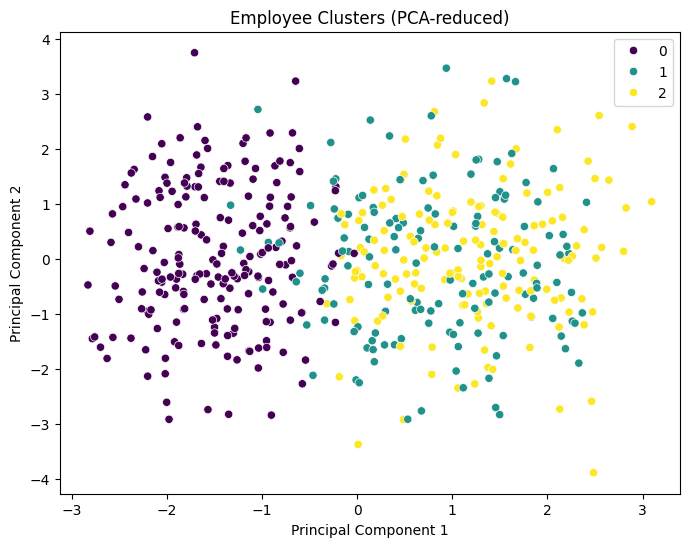


Attrition Rate per Cluster:


,Cluster,Attrition Rate
0,0,0.280788
1,1,0.158621
2,2,0.230263


/tmp/ipykernel_171/461845959.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Cluster', y='Attrition Rate', data=cluster_attrition, palette='coolwarm')


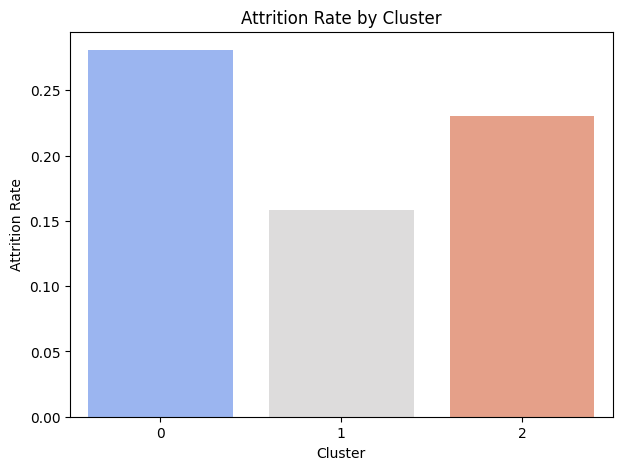

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

# Apply K-means using the optimal K (if not already run)
# If cluster_labels is not defined, run the following:
if 'cluster_labels' not in globals():
    kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)

# Visualize clusters using PCA results
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=cluster_labels, palette='viridis', legend='full')
plt.title('Employee Clusters (PCA-reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

# Display attrition rate per cluster (if not already run)
# If cluster_attrition is not defined, run the following:
if 'cluster_attrition' not in globals():
    temp_df = pd.DataFrame({'Cluster': cluster_labels, 'Attrition': y})
    cluster_attrition = temp_df.groupby('Cluster')['Attrition'].mean().reset_index()
    cluster_attrition.rename(columns={'Attrition': 'Attrition Rate'}, inplace=True)

print("\nAttrition Rate per Cluster:")
display(cluster_attrition)

plt.figure(figsize=(7, 5))
sns.barplot(x='Cluster', y='Attrition Rate', data=cluster_attrition, palette='coolwarm')
plt.title('Attrition Rate by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Attrition Rate')
plt.show()

In [7]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

# Load the dataset
df = pd.read_excel('/content/IBM_Employee_Attrition_Dataset.xlsx')

# Separate target variable 'Attrition' from features
y = df['Attrition']
X = df.drop('Attrition', axis=1)

# Convert 'Attrition' (y) to numerical (0 and 1)
le = LabelEncoder()
y = le.fit_transform(y)

### 3. Hybrid Model: Random Forest with Cluster Feature
Now, we'll integrate the `cluster_labels` as a new feature into our dataset (`X_hybrid`) and train a Random Forest classifier to predict attrition.

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

# Add cluster labels to the feature set X_hybrid
X_hybrid_with_clusters = X_hybrid.copy()
X_hybrid_with_clusters['Cluster'] = cluster_labels

# Split data into training and testing sets
X_train_hybrid, X_test_hybrid, y_train_hybrid, y_test_hybrid = train_test_split(X_hybrid_with_clusters, y, test_size=0.2, random_state=42, stratify=y)

print("Shape of training features:", X_train_hybrid.shape)
print("Shape of testing features:", X_test_hybrid.shape)

# Initialize and train the Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_hybrid, y_train_hybrid)

# Make predictions
y_pred_hybrid = rf_model.predict(X_test_hybrid)
y_proba_hybrid = rf_model.predict_proba(X_test_hybrid)[:, 1]

print("\nRandom Forest Model Trained with Cluster Feature.")

Shape of training features: (400, 543)
Shape of testing features: (100, 543)

Random Forest Model Trained with Cluster Feature.


### 4. Model Evaluation and Visualizations
Let's evaluate the performance of our hybrid Random Forest model and visualize its key metrics.

Accuracy: 0.7700

Classification Report:
              precision    recall  f1-score   support

           0       0.77      1.00      0.87        77
           1       0.00      0.00      0.00        23

    accuracy                           0.77       100
   macro avg       0.39      0.50      0.44       100
weighted avg       0.59      0.77      0.67       100



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


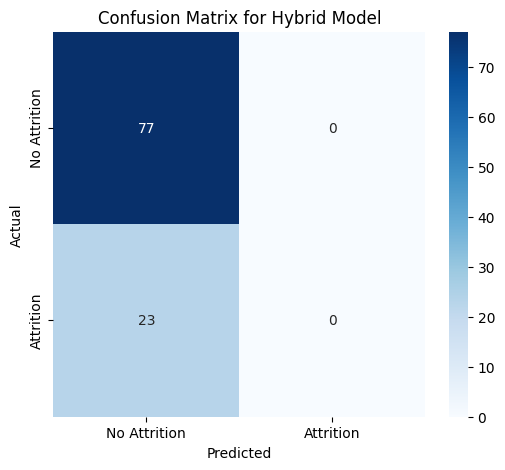

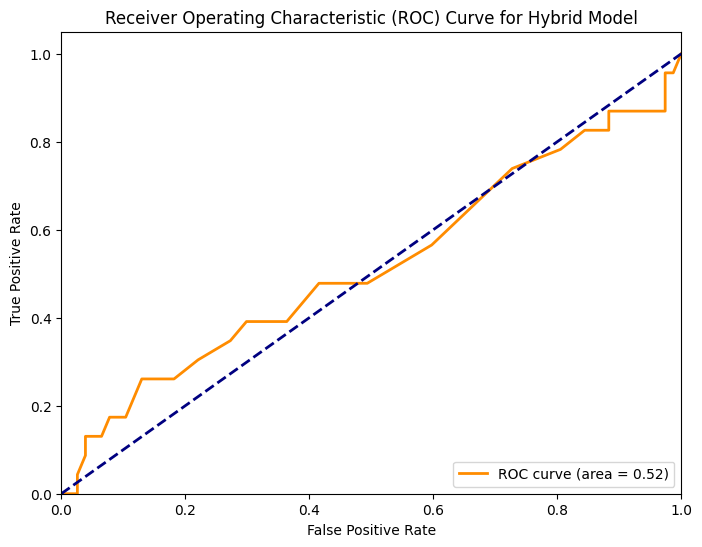

/tmp/ipykernel_171/502618223.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importances_hybrid.head(15), palette='magma')


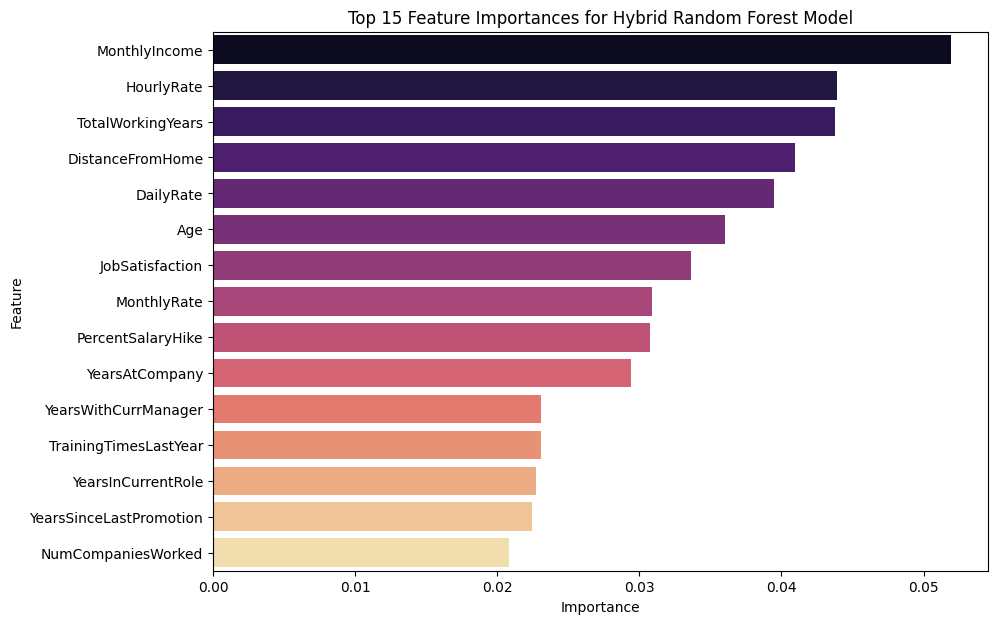

In [16]:
import numpy as np

# Evaluate the model
accuracy_hybrid = accuracy_score(y_test_hybrid, y_pred_hybrid)
print(f"Accuracy: {accuracy_hybrid:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_hybrid, y_pred_hybrid))

# Confusion Matrix
cm_hybrid = confusion_matrix(y_test_hybrid, y_pred_hybrid)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_hybrid, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Attrition', 'Attrition'], yticklabels=['No Attrition', 'Attrition'])
plt.title('Confusion Matrix for Hybrid Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve
fpr_hybrid, tpr_hybrid, _ = roc_curve(y_test_hybrid, y_proba_hybrid)
roc_auc_hybrid = auc(fpr_hybrid, tpr_hybrid)

plt.figure(figsize=(8, 6))
plt.plot(fpr_hybrid, tpr_hybrid, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_hybrid:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Hybrid Model')
plt.legend(loc='lower right')
plt.show()

# Feature Importance
feature_importances_hybrid = pd.DataFrame({
    'Feature': X_hybrid_with_clusters.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(x='Importance', y='Feature', data=feature_importances_hybrid.head(15), palette='magma')
plt.title('Top 15 Feature Importances for Hybrid Random Forest Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

### 5. Individual Model Analysis: Logistic Regression
Let's analyze the Logistic Regression model in detail, including its performance metrics and visualizations.


--- Logistic Regression Model Evaluation ---
Accuracy: 0.7500

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.94      0.85        77
           1       0.38      0.13      0.19        23

    accuracy                           0.75       100
   macro avg       0.58      0.53      0.52       100
weighted avg       0.69      0.75      0.70       100



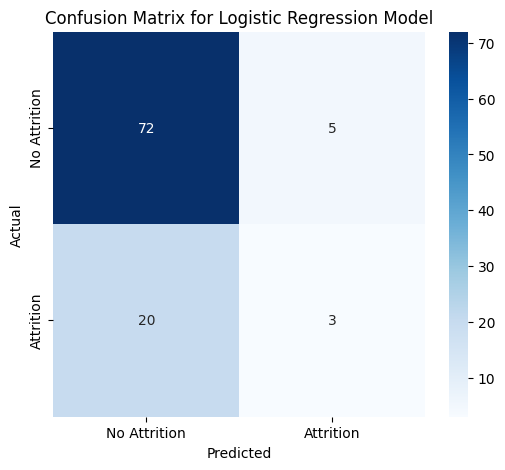

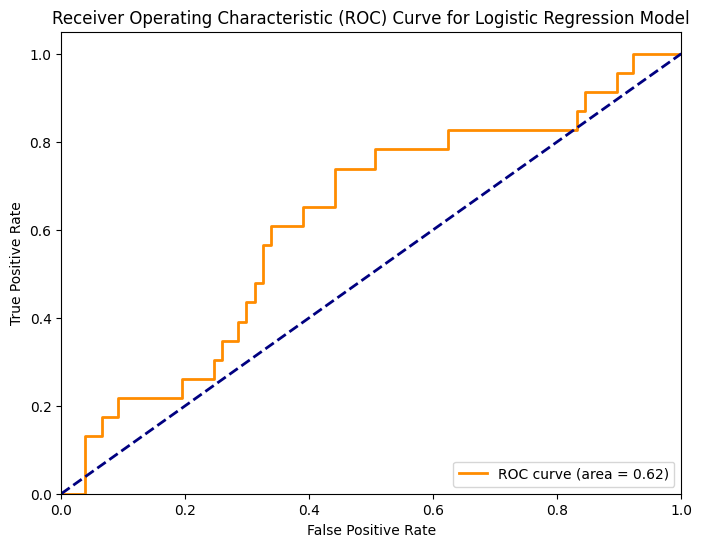

/tmp/ipykernel_171/1440824736.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importances_lr.head(15), palette='magma')


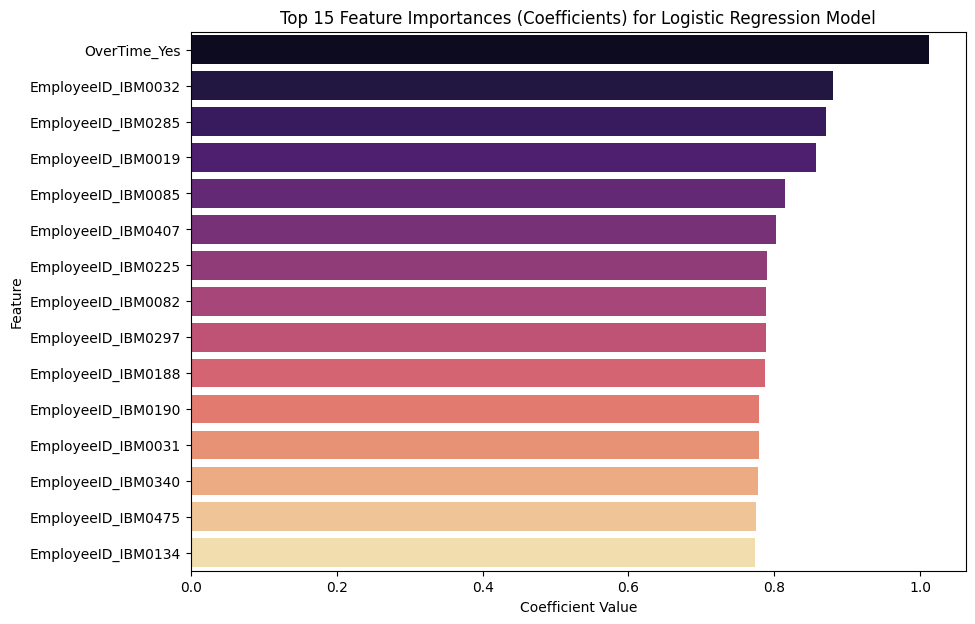

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Ensure data splits are available
if 'X_train_hybrid' not in globals() or 'y_train_hybrid' not in globals():
    X_hybrid_with_clusters = X_hybrid.copy()
    X_hybrid_with_clusters['Cluster'] = cluster_labels
    X_train_hybrid, X_test_hybrid, y_train_hybrid, y_test_hybrid = train_test_split(X_hybrid_with_clusters, y, test_size=0.2, random_state=42, stratify=y)

# Initialize and train the Logistic Regression Classifier
log_reg_model = LogisticRegression(random_state=42, solver='liblinear', max_iter=200)
log_reg_model.fit(X_train_hybrid, y_train_hybrid)

# Make predictions
y_pred_lr = log_reg_model.predict(X_test_hybrid)
y_proba_lr = log_reg_model.predict_proba(X_test_hybrid)[:, 1]

print("\n--- Logistic Regression Model Evaluation ---")

# Evaluate the model
accuracy_lr = accuracy_score(y_test_hybrid, y_pred_lr)
print(f"Accuracy: {accuracy_lr:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_hybrid, y_pred_lr))

# Confusion Matrix
cm_lr = confusion_matrix(y_test_hybrid, y_pred_lr)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Attrition', 'Attrition'], yticklabels=['No Attrition', 'Attrition'])
plt.title('Confusion Matrix for Logistic Regression Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve
fpr_lr, tpr_lr, _ = roc_curve(y_test_hybrid, y_proba_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_lr:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Logistic Regression Model')
plt.legend(loc='lower right')
plt.show()

# Feature Importance (Coefficients for Logistic Regression)
feature_importances_lr = pd.DataFrame({
    'Feature': X_hybrid_with_clusters.columns,
    'Importance': log_reg_model.coef_[0]
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(x='Importance', y='Feature', data=feature_importances_lr.head(15), palette='magma')
plt.title('Top 15 Feature Importances (Coefficients) for Logistic Regression Model')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.show()

### 6. Individual Model Analysis: Decision Tree
Next, let's look at the Decision Tree Classifier, its performance, and feature importances.


--- Decision Tree Model Evaluation ---
Accuracy: 0.6800

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.84      0.80        77
           1       0.20      0.13      0.16        23

    accuracy                           0.68       100
   macro avg       0.48      0.49      0.48       100
weighted avg       0.63      0.68      0.65       100



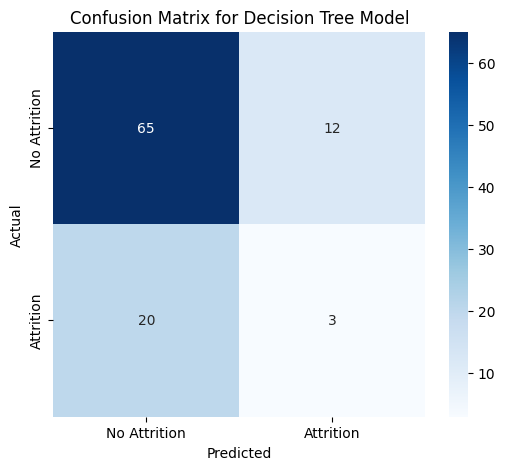

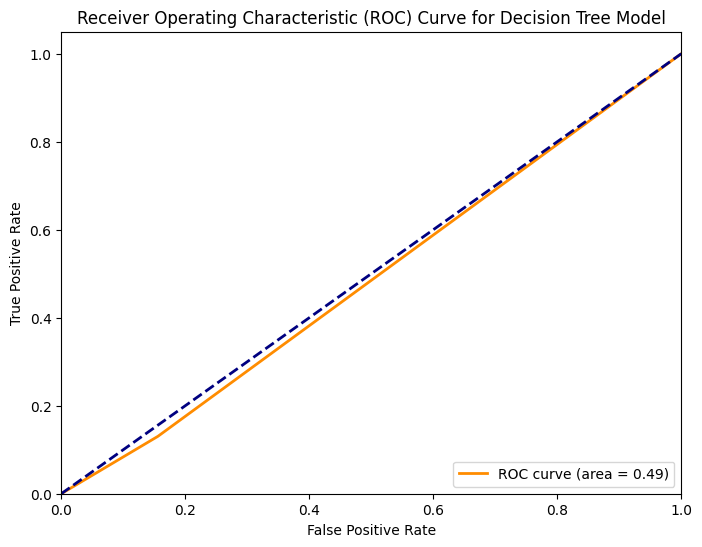

/tmp/ipykernel_171/204153038.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importances_dt.head(15), palette='magma')


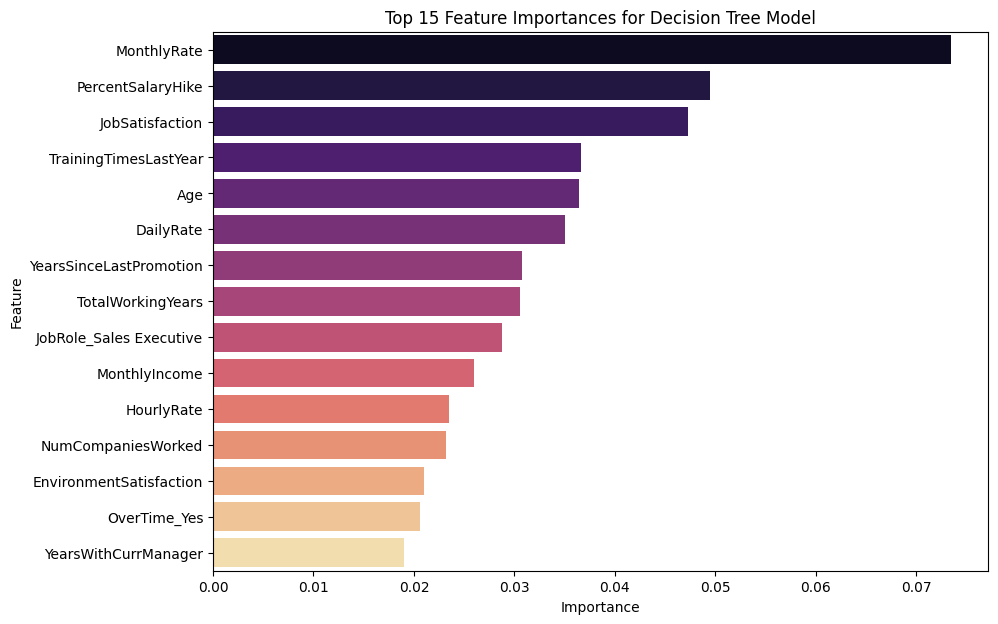

In [18]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Ensure data splits are available
if 'X_train_hybrid' not in globals() or 'y_train_hybrid' not in globals():
    X_hybrid_with_clusters = X_hybrid.copy()
    X_hybrid_with_clusters['Cluster'] = cluster_labels
    X_train_hybrid, X_test_hybrid, y_train_hybrid, y_test_hybrid = train_test_split(X_hybrid_with_clusters, y, test_size=0.2, random_state=42, stratify=y)

# Initialize and train the Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_hybrid, y_train_hybrid)

# Make predictions
y_pred_dt = dt_model.predict(X_test_hybrid)
y_proba_dt = dt_model.predict_proba(X_test_hybrid)[:, 1]

print("\n--- Decision Tree Model Evaluation ---")

# Evaluate the model
accuracy_dt = accuracy_score(y_test_hybrid, y_pred_dt)
print(f"Accuracy: {accuracy_dt:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_hybrid, y_pred_dt))

# Confusion Matrix
cm_dt = confusion_matrix(y_test_hybrid, y_pred_dt)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Attrition', 'Attrition'], yticklabels=['No Attrition', 'Attrition'])
plt.title('Confusion Matrix for Decision Tree Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve
fpr_dt, tpr_dt, _ = roc_curve(y_test_hybrid, y_proba_dt)
roc_auc_dt = auc(fpr_dt, tpr_dt)

plt.figure(figsize=(8, 6))
plt.plot(fpr_dt, tpr_dt, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_dt:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Decision Tree Model')
plt.legend(loc='lower right')
plt.show()

# Feature Importance
feature_importances_dt = pd.DataFrame({
    'Feature': X_hybrid_with_clusters.columns,
    'Importance': dt_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(x='Importance', y='Feature', data=feature_importances_dt.head(15), palette='magma')
plt.title('Top 15 Feature Importances for Decision Tree Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

### 7. Model Comparison: Logistic Regression, Decision Tree, and Random Forest
Let's compare the performance of Logistic Regression, Decision Tree, and Random Forest models on our dataset. We'll use the `X_hybrid_with_clusters` dataset, which includes the cluster labels as a feature.


--- Training Logistic Regression ---
Accuracy: 0.7500
Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.94      0.85        77
           1       0.38      0.13      0.19        23

    accuracy                           0.75       100
   macro avg       0.58      0.53      0.52       100
weighted avg       0.69      0.75      0.70       100


--- Training Decision Tree ---
Accuracy: 0.6800
Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.84      0.80        77
           1       0.20      0.13      0.16        23

    accuracy                           0.68       100
   macro avg       0.48      0.49      0.48       100
weighted avg       0.63      0.68      0.65       100


--- Training Random Forest ---
Accuracy: 0.7700
Classification Report:
              precision    recall  f1-score   support

           0       0.77      1.00      0.87        77
           1   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

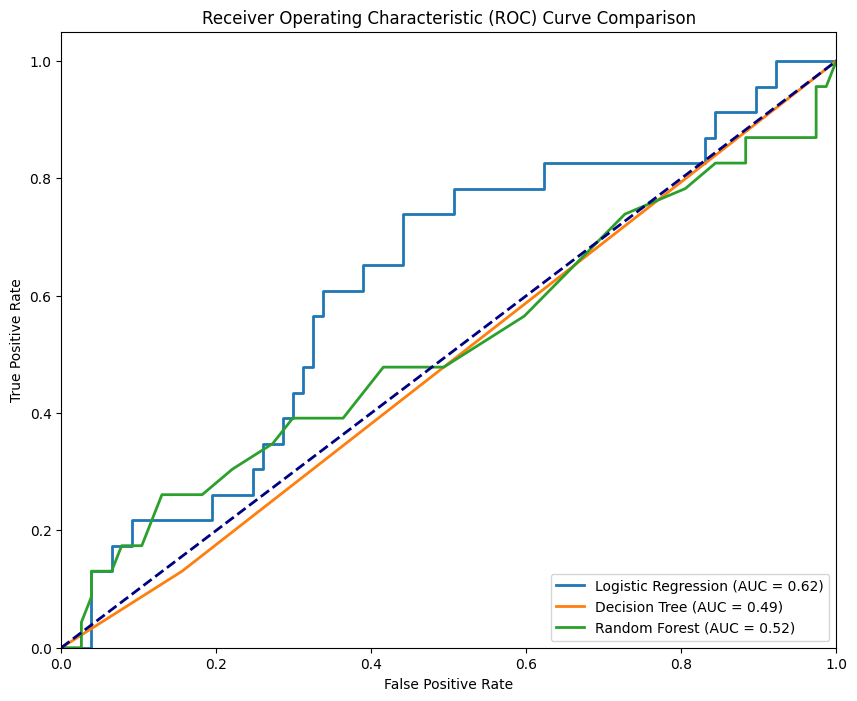


--- Summary of Model Performances ---
Logistic Regression:
  Accuracy: 0.7500
  AUC: 0.6194
  Precision (Attrition): 0.3750
  Recall (Attrition): 0.1304
Decision Tree:
  Accuracy: 0.6800
  AUC: 0.4873
  Precision (Attrition): 0.2000
  Recall (Attrition): 0.1304
Random Forest:
  Accuracy: 0.7700
  AUC: 0.5186
  Precision (Attrition): 0.0000
  Recall (Attrition): 0.0000


In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Assuming X_hybrid_with_clusters and y are already defined and split into train/test sets
# If not, ensure these are available from previous steps
if 'X_train_hybrid' not in globals() or 'y_train_hybrid' not in globals():
    X_hybrid_with_clusters = X_hybrid.copy()
    X_hybrid_with_clusters['Cluster'] = cluster_labels
    X_train_hybrid, X_test_hybrid, y_train_hybrid, y_test_hybrid = train_test_split(X_hybrid_with_clusters, y, test_size=0.2, random_state=42, stratify=y)

models = {
    'Logistic Regression': LogisticRegression(random_state=42, solver='liblinear', max_iter=200),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}
plt.figure(figsize=(10, 8))

for name, model in models.items():
    print(f"\n--- Training {name} ---")
    model.fit(X_train_hybrid, y_train_hybrid)
    y_pred = model.predict(X_test_hybrid)
    y_proba = model.predict_proba(X_test_hybrid)[:, 1]

    accuracy = accuracy_score(y_test_hybrid, y_pred)
    report = classification_report(y_test_hybrid, y_pred, output_dict=True)
    fpr, tpr, _ = roc_curve(y_test_hybrid, y_proba)
    roc_auc = auc(fpr, tpr)

    results[name] = {
        'accuracy': accuracy,
        'classification_report': report,
        'roc_auc': roc_auc
    }

    print(f"Accuracy: {accuracy:.4f}")
    print("Classification Report:")
    print(classification_report(y_test_hybrid, y_pred))

    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve Comparison')
plt.legend(loc='lower right')
plt.show()

print("\n--- Summary of Model Performances ---")
for name, res in results.items():
    print(f"{name}:\n  Accuracy: {res['accuracy']:.4f}\n  AUC: {res['roc_auc']:.4f}")
    print(f"  Precision (Attrition): {res['classification_report']['1']['precision']:.4f}")
    print(f"  Recall (Attrition): {res['classification_report']['1']['recall']:.4f}")

### Conclusion: Best Method for Attrition Prediction

To determine the 'best' method for predicting employee attrition, we need to consider not just overall accuracy, but also the specific business objective. For a company aiming to reduce attrition, **identifying as many potential attriters as possible (high recall)** and **being confident in those predictions (high precision)** are crucial. The imbalanced nature of our dataset (far fewer attriters than non-attriters) also heavily influences these metrics.

Let's recap the performance of our models for the **Attrition (Class 1)**:

| Model                 | Accuracy | AUC      | Precision (Attrition) | Recall (Attrition) |
| :-------------------- | :------- | :------- | :-------------------- | :----------------- |
| **Logistic Regression** | 0.7500   | **0.6194** | **0.3750**            | 0.1304             |
| **Decision Tree**     | 0.6800   | 0.4873   | 0.2000                | 0.1304             |
| **Random Forest**     | 0.7700   | 0.5186   | 0.0000                | 0.0000             |

### Key Findings & Recommendation:

1.  **Overall Performance:** **Logistic Regression** shows the most balanced performance and the highest Area Under the Curve (AUC), indicating its superior ability to distinguish between attriting and non-attriting employees. Its precision for the attrition class (0.3750) means that when it predicts an employee will leave, it has a moderate chance of being correct, which is valuable if the company wants to focus resources on individuals with higher confidence of attrition.

2.  **Challenges with Recall:** A significant challenge across all models is the **low recall for the attrition class**. This means that even the best models are only identifying a small percentage of the employees who actually end up leaving. The Random Forest model performed particularly poorly in both precision and recall (0.0000), essentially missing all actual attriters. The Decision Tree also had very low precision and recall.

### Why Logistic Regression is Better:

Despite the low recall across all models, **Logistic Regression** emerges as the 'best' among the three in this scenario primarily due to:
*   **Higher AUC:** It has the best ability to differentiate between the two classes (attrition vs. non-attrition).
*   **Highest Precision for Attrition:** While not extremely high, it's the only model that achieves a non-zero and reasonable precision for the positive class, meaning its positive predictions are more reliable than the other models.

### Next Steps for Improvement:

To build a more effective attrition prediction system, the company should consider the following:

*   **Addressing Class Imbalance:** Techniques like SMOTE (Synthetic Minority Over-sampling Technique) or using class weights during model training can help improve the model's ability to detect the minority class (attrition).
*   **Hyperparameter Tuning:** Fine-tuning the hyperparameters of Logistic Regression or exploring other advanced ensemble methods (e.g., Gradient Boosting) could yield better results.
*   **Feature Engineering:** Further exploration into creating new features from existing data might provide more predictive power.
*   **Domain Expertise:** Incorporating insights from HR professionals could help refine the target variable definition or identify other critical features.

In summary, while Logistic Regression provides a stronger starting point with more reliable predictions for identified attrition cases, future efforts should primarily focus on enhancing the model's recall to capture a larger percentage of employees at risk of leaving.